# Análisis estadístico del TFG — Punto 0

## ¿Cómo juega cada bot?

Este análisis estudia el comportamiento de los bots a partir de las métricas registradas en el bloque `*** EXPERIMENT ***` de los logs.

Se comparan los distintos tipos de bot, los estilos de juego de los LLM y, adicionalmente, si un mismo estilo presenta un comportamiento diferente dependiendo del modelo LLM utilizado.

Las métricas principales son VPIP, PFR, 3Bet, WTSD, WSD, WWSF y AF.


## Librerías y configuración

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================

BASE_DIR = Path.cwd()

LOG_DIR = BASE_DIR / "server" / "logs" / "history"
OUTPUT_DIR = BASE_DIR / "resultados_analisis"
OUTPUT_DIR.mkdir(exist_ok=True)

METRICAS = [
    "VPIP",
    "PFR",
    "3Bet",
    "WTSD",
    "WSD",
    "WWSF"
]

TIPOS_BOT = [
    "BOT_LLM",
    "BOT_NN",
    "BOT_FSM"
]

# Orden solicitado para los estilos.
ESTILOS = [
    "TIGHT_PASSIVE",
    "TIGHT_AGGRESSIVE",
    "LOOSE_PASSIVE",
    "LOOSE_AGGRESSIVE",
    "MANIAC",
    "DEFAULT"
]

NOMBRES_ESTILOS = {
    "TIGHT_PASSIVE": "Tight Passive",
    "TIGHT_AGGRESSIVE": "Tight Aggressive",
    "LOOSE_PASSIVE": "Loose Passive",
    "LOOSE_AGGRESSIVE": "Loose Aggressive",
    "MANIAC": "Maniac",
    "DEFAULT": "Default"
}

print("Directorio de logs:")
print(LOG_DIR)
print("Existe:", LOG_DIR.exists())

print()
print("Directorio de resultados:")
print(OUTPUT_DIR)


Directorio de logs:
C:\Valeria\TFG_Poker\tfgpoker\server\logs\history
Existe: True

Directorio de resultados:
C:\Valeria\TFG_Poker\tfgpoker\resultados_analisis


## Lectura y comprobación de los datos

In [2]:
# ============================================================
# FUNCIONES DE LECTURA
# ============================================================

def extraer_campo(linea, campo):
    patron = rf"^{re.escape(campo)}\.*\s+(.+)$"
    resultado = re.match(
        patron,
        linea.strip(),
        re.IGNORECASE
    )

    if resultado:
        return resultado.group(1).strip()

    return None


def convertir_si_no(valor):
    if valor is None:
        return np.nan

    return 1 if valor.strip().upper() == "YES" else 0


def normalizar_tipo(valor):
    if valor is None:
        return None

    return valor.strip().upper()


def normalizar_estilo(valor):
    """
    IMPORTANTE:
    El estilo se obtiene SIEMPRE del campo Style del bloque
    *** EXPERIMENT ***.

    Mapeo exacto de getPlayerStyle():

        DEFAULT -> DEFAULT
        TP      -> TIGHT_PASSIVE
        TAG     -> TIGHT_AGGRESSIVE
        LP      -> LOOSE_PASSIVE
        LAG     -> LOOSE_AGGRESSIVE
        MANIAC  -> MANIAC
    """

    if valor is None:
        return None

    equivalencias = {
        "DEFAULT": "DEFAULT",
        "TP": "TIGHT_PASSIVE",
        "TAG": "TIGHT_AGGRESSIVE",
        "LP": "LOOSE_PASSIVE",
        "LAG": "LOOSE_AGGRESSIVE",
        "MANIAC": "MANIAC"
    }

    return equivalencias.get(
        valor.strip().upper(),
        valor.strip().upper()
    )


def parsear_hand(path):

    texto = path.read_text(
        encoding="utf-8",
        errors="replace"
    )

    lineas = texto.splitlines()

    match_id = path.parent.name

    hand_match = re.search(
        r"hand_(\d+)\.log$",
        path.name,
        re.IGNORECASE
    )

    hand_id = (
        int(hand_match.group(1))
        if hand_match
        else None
    )

    jugadores = []
    actual = None
    en_experiment = False

    # ========================================================
    # BLOQUE EXPERIMENT
    # ========================================================

    for linea in lineas:

        s = linea.strip()

        if s == "*** EXPERIMENT ***":
            en_experiment = True
            continue

        if not en_experiment:
            continue

        if s.startswith("--------- PLAYER"):

            if actual is not None:
                jugadores.append(actual)

            actual = {
                "Match": match_id,
                "Hand": hand_id,
                "File": path.name,

                "Player": None,
                "PlayerId": None,
                "Type": None,
                "Model": None,
                "Style": None,
                "Position": None,

                "Initial stack": np.nan,
                "Final stack": np.nan,

                "VPIP": np.nan,
                "PFR": np.nan,
                "3Bet": np.nan,
                "WTSD": np.nan,
                "WSD": np.nan,
                "WWSF": np.nan,

                # Acciones para calcular AF:
                "Calls": 0,
                "Bets": 0,
                "Raises": 0,
                "Folds": 0,
                "Checks": 0,
                "AllIns": 0
            }

            continue

        if actual is None:
            continue

        # ----------------------------------------------------
        # Campos básicos
        # ----------------------------------------------------

        campos = [
            "Player",
            "PlayerId",
            "Type",
            "Model",
            "Style",
            "Position",
            "Initial stack",
            "Final stack",
            "Hand result"
        ]

        encontrado = False

        for campo in campos:

            valor = extraer_campo(
                s,
                campo
            )

            if valor is None:
                continue

            if campo == "PlayerId":

                try:
                    valor = int(valor)
                except ValueError:
                    pass

            elif campo in ["Initial stack", "Final stack"]:

                try:
                    valor = float(valor)
                except ValueError:
                    valor = np.nan

            elif campo == "Type":

                valor = normalizar_tipo(valor)

            elif campo == "Style":

                # REGLA FUNDAMENTAL:
                # nunca inferir el estilo desde el nombre,
                # modelo o acciones.
                valor = normalizar_estilo(valor)

            actual[campo] = valor
            encontrado = True
            break

        if encontrado:
            continue

        # ----------------------------------------------------
        # Métricas YES/NO
        # ----------------------------------------------------

        for metrica in METRICAS:

            valor = extraer_campo(
                s,
                metrica
            )

            if valor is not None:

                actual[metrica] = convertir_si_no(
                    valor
                )

                break

    if actual is not None:
        jugadores.append(actual)

    # ========================================================
    # ACCIONES DEL HISTORIAL
    # ========================================================
    #
    # AF = (Bets + Raises) / Calls
    #
    # Las acciones se extraen del historial de la mano,
    # mientras que Style/Type/Model salen del EXPERIMENT.
    # ========================================================

    acciones = {}

    for jugador in jugadores:
        nombre = jugador.get("Player")

        if nombre:
            acciones[nombre] = {
                "Calls": 0,
                "Bets": 0,
                "Raises": 0,
                "Folds": 0,
                "Checks": 0,
                "AllIns": 0
            }

    en_historial = False

    for linea in lineas:

        s = linea.strip()

        if s == "*** HOLE CARDS ***":
            en_historial = True
            continue

        if not en_historial:
            continue

        if (
            s.startswith("*** SHOW DOWN ***")
            or s.startswith("*** SUMMARY ***")
            or s.startswith("*** EXPERIMENT ***")
        ):
            break

        if (
            s.startswith("*** FLOP ***")
            or s.startswith("*** TURN ***")
            or s.startswith("*** RIVER ***")
        ):
            continue

        if ":" not in s:
            continue

        nombre, accion = s.split(":", 1)

        nombre = nombre.strip()
        accion = accion.strip().lower()

        if nombre not in acciones:
            continue

        # El all-in se contabiliza además como acción agresiva.
        if "fold" in accion:
            acciones[nombre]["Folds"] += 1

        elif "check" in accion:
            acciones[nombre]["Checks"] += 1

        elif "call" in accion:
            acciones[nombre]["Calls"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "raise" in accion:
            acciones[nombre]["Raises"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "bet" in accion:
            acciones[nombre]["Bets"] += 1

            if "all-in" in accion:
                acciones[nombre]["AllIns"] += 1

        elif "is all-in" in accion:
            acciones[nombre]["Bets"] += 1
            acciones[nombre]["AllIns"] += 1

    for jugador in jugadores:
        nombre = jugador.get("Player")

        if nombre in acciones:
            jugador.update(
                acciones[nombre]
            )

    return jugadores


# ============================================================
# LEER TODOS LOS LOGS
# ============================================================

log_files = sorted(
    LOG_DIR.rglob("hand_*.log")
)

print("Logs encontrados:", len(log_files))

datos = []

for archivo in log_files:

    try:
        datos.extend(
            parsear_hand(archivo)
        )

    except Exception as error:

        print()
        print("ERROR:", archivo)
        print(error)

df = pd.DataFrame(datos)

print()
print("Registros de jugadores:", len(df))

# ============================================================
# COMPROBACIONES
# ============================================================

print()
print("========== TYPES ==========")

display(
    df["Type"].value_counts(
        dropna=False
    )
)

print()
print("========== MODELOS ==========")

display(
    df["Model"].value_counts(
        dropna=False
    )
)

print()
print("========== ESTILOS ==========")

display(
    df["Style"].value_counts(
        dropna=False
    )
)

print()
print("========== COMBINACIONES TYPE / MODEL / STYLE ==========")

display(
    df[
        ["Type", "Model", "Style"]
    ]
    .drop_duplicates()
    .sort_values(
        ["Type", "Model", "Style"]
    )
)

print()
print("========== DATOS DE BOTS ==========")

df_bots = df[
    df["Type"].isin(TIPOS_BOT)
].copy()

display(
    df_bots.head(10)
)

print()
print("Registros de bots:", len(df_bots))

print()
print("========== ESTILOS LLM Y NÚMERO DE REGISTROS ==========")

df_llm = df_bots[
    df_bots["Type"] == "BOT_LLM"
].copy()

conteo_estilos = (
    df_llm["Style"]
    .value_counts()
    .reindex(ESTILOS)
)

display(
    conteo_estilos.rename(
        index=NOMBRES_ESTILOS
    ).rename("Manos")
)


Logs encontrados: 115

Registros de jugadores: 555

========== TYPES ==========


Type
BOT_LLM    242
HUMAN      111
BOT_NN     101
BOT_FSM    101
Name: count, dtype: int64


========== MODELOS ==========


Model
Llama3-8B        221
-                111
AgentCFR_1       101
ClassifierFSM    101
Gemini            21
Name: count, dtype: int64


========== ESTILOS ==========


...

,Type,Model,Style
4,BOT_FSM,ClassifierFSM,DEFAULT
1,BOT_LLM,Gemini,DEFAULT
2,BOT_LLM,Llama3-8B,DEFAULT
107,BOT_LLM,Llama3-8B,LOOSE_AGGRESSIVE
252,BOT_LLM,Llama3-8B,LOOSE_PASSIVE
426,BOT_LLM,Llama3-8B,MANIAC
251,BOT_LLM,Llama3-8B,TIGHT_AGGRESSIVE
106,BOT_LLM,Llama3-8B,TIGHT_PASSIVE
3,BOT_NN,AgentCFR_1,DEFAULT
0,HUMAN,-,DEFAULT



========== DATOS DE BOTS ==========


,Match,Hand,File,Player,PlayerId,Type,Model,Style,Position,Initial stack,...,WTSD,WSD,WWSF,Calls,Bets,Raises,Folds,Checks,AllIns,Hand result
1,match_20260814_211527_418_001,1,hand_0001.log,GeminiLLM#1-DEFAULT#1,1,BOT_LLM,Gemini,DEFAULT,SB,100.0,...,0,0,0,0,0,0,1,0,0,LOST
2,match_20260814_211527_418_001,1,hand_0001.log,LlamaPokerLLM#2-DEFAULT#2,2,BOT_LLM,Llama3-8B,DEFAULT,BB,100.0,...,1,0,0,3,1,0,0,2,1,LOST
3,match_20260814_211527_418_001,1,hand_0001.log,DeepCFR#3-DEFAULT#3,3,BOT_NN,AgentCFR_1,DEFAULT,UTG,100.0,...,0,0,0,0,0,1,1,2,0,LOST
4,match_20260814_211527_418_001,1,hand_0001.log,FSM#4-DEFAULT#4,4,BOT_FSM,ClassifierFSM,DEFAULT,CO,100.0,...,1,0,0,1,1,1,0,2,1,LOST
5,match_20260814_211527_418_001,2,hand_0002.log,GeminiLLM#1-DEFAULT#1,1,BOT_LLM,Gemini,DEFAULT,BTN,99.0,...,0,0,0,2,0,1,1,0,0,LOST
6,match_20260814_211527_418_001,2,hand_0002.log,LlamaPokerLLM#2-DEFAULT#2,2,BOT_LLM,Llama3-8B,DEFAULT,BB,0.0,...,1,0,0,0,0,0,0,0,0,LOST
7,match_20260814_211527_418_001,2,hand_0002.log,DeepCFR#3-DEFAULT#3,3,BOT_NN,AgentCFR_1,DEFAULT,SB,96.0,...,1,1,1,0,0,2,0,3,0,WON
8,match_20260814_211527_418_001,2,hand_0002.log,FSM#4-DEFAULT#4,4,BOT_FSM,ClassifierFSM,DEFAULT,CO,0.0,...,1,0,0,0,0,0,0,0,0,LOST
10,match_20260814_211527_418_001,3,hand_0003.log,DeepCFR#3-DEFAULT#3,3,BOT_NN,AgentCFR_1,DEFAULT,BTN,122.0,...,1,0,0,1,0,1,0,2,0,LOST
11,match_20260814_211527_418_001,3,hand_0003.log,FSM#4-DEFAULT#4,4,BOT_FSM,ClassifierFSM,DEFAULT,CO,0.0,...,1,0,0,0,0,0,0,0,0,LOST



Registros de bots: 444

========== ESTILOS LLM Y NÚMERO DE REGISTROS ==========


Style
Tight Passive       46
Tight Aggressive    45
Loose Passive       45
Loose Aggressive    48
Maniac              16
Default             42
Name: Manos, dtype: int64

# 0. ¿Cómo juega cada bot?

Se analiza el perfil de juego de los bots mediante VPIP, PFR, 3Bet, WTSD, WSD, WWSF y AF.

Se comparan los tipos de bot y, en los LLM, los diferentes estilos.

Además, se analiza si **un mismo estilo se comporta de forma diferente según el modelo LLM**.


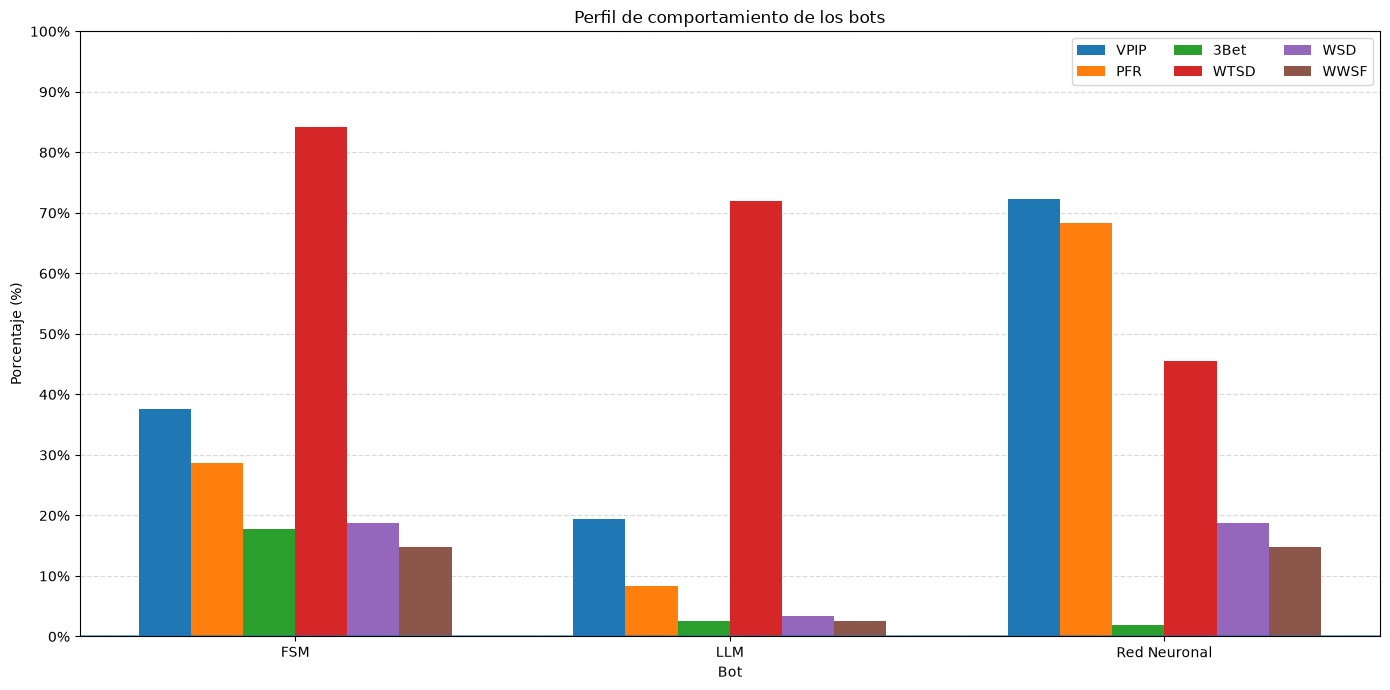

In [3]:
# ============================================================
# GRÁFICA 1 — BARRAS: PERFIL DE LOS BOTS
# ============================================================

def calcular_metricas_por_grupo(datos, grupo):

    return (
        datos
        .groupby(grupo, dropna=False)[METRICAS]
        .mean()
        * 100
    )


resumen_bots = calcular_metricas_por_grupo(
    df_bots,
    "Type"
)

# Etiquetas más legibles.
nombres_tipos = {
    "BOT_LLM": "LLM",
    "BOT_NN": "Red Neuronal",
    "BOT_FSM": "FSM"
}

resumen_bots.index = [
    nombres_tipos.get(
        x,
        x
    )
    for x in resumen_bots.index
]

fig, ax = plt.subplots(
    figsize=(14, 7)
)

x = np.arange(
    len(resumen_bots)
)

width = 0.12

offsets = np.linspace(
    -2.5 * width,
    2.5 * width,
    len(METRICAS)
)

for offset, metrica in zip(
    offsets,
    METRICAS
):

    ax.bar(
        x + offset,
        resumen_bots[metrica],
        width=width,
        label=metrica
    )

ax.set_title(
    "Perfil de comportamiento de los bots"
)

ax.set_ylabel(
    "Porcentaje (%)"
)

ax.set_xlabel(
    "Bot"
)

ax.set_ylim(
    0,
    100
)

# Mostrar claramente los extremos del eje.
ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    100,
    linewidth=1.2,
    alpha=0.65
)

ax.set_yticks(
    np.arange(0, 101, 10)
)

ax.set_yticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.grid(
    False
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.xaxis.grid(
    False
)

ax.set_axisbelow(
    True
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    resumen_bots.index
)

ax.legend(
    ncol=3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_0_bots_barras.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


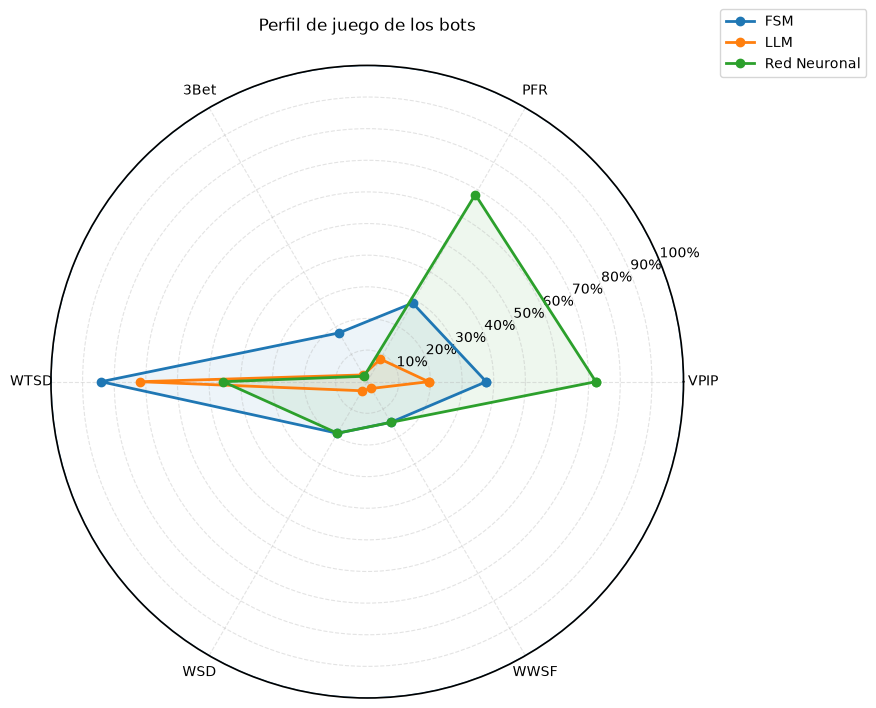

In [4]:
# ============================================================
# GRÁFICA 2 — RADAR: PERFIL DE LOS BOTS
# ============================================================

datos_radar = resumen_bots[
    METRICAS
].fillna(0)

angulos = np.linspace(
    0,
    2 * np.pi,
    len(METRICAS),
    endpoint=False
).tolist()

angulos += angulos[:1]

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={
        "polar": True
    }
)

for i, nombre in enumerate(
    datos_radar.index
):

    valores = datos_radar.loc[
        nombre,
        METRICAS
    ].tolist()

    valores += valores[:1]

    ax.plot(
        angulos,
        valores,
        marker="o",
        linewidth=2,
        label=nombre
    )

    ax.fill(
        angulos,
        valores,
        alpha=0.08
    )

ax.set_ylim(
    0,
    100
)

# Marcar claramente los extremos 0% y 100%.
ax.spines["polar"].set_linewidth(1.2)

# Mostrar claramente los extremos del eje.
ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    100,
    linewidth=1.2,
    alpha=0.65
)

ax.set_yticks(
    np.arange(0, 101, 10)
)

ax.set_yticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.set_xticks(
    angulos[:-1]
)

ax.set_xticklabels(
    METRICAS
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

ax.set_title(
    "Perfil de juego de los bots",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.30, 1.10)
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_0_bots_radar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


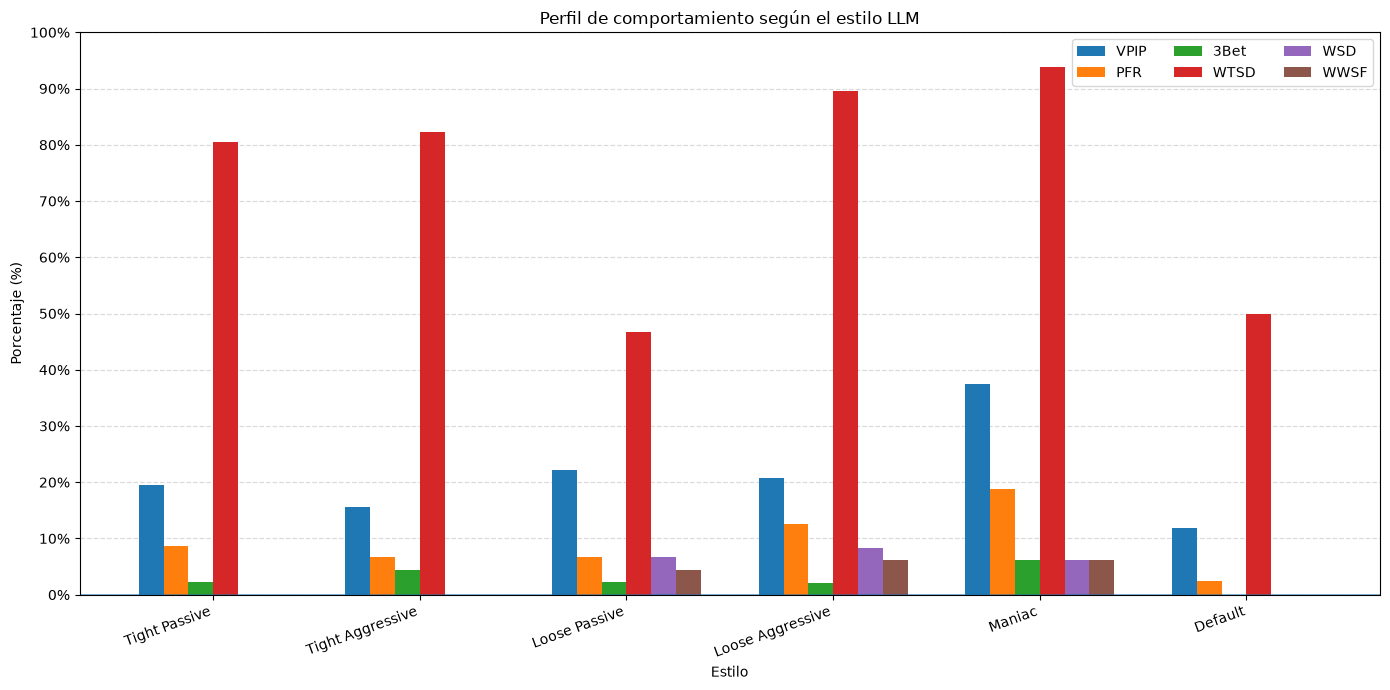

In [5]:
# ============================================================
# GRÁFICA 3 — BARRAS: ESTILOS LLM
# ============================================================

resumen_estilos = (
    df_llm
    .groupby(
        "Style",
        observed=True
    )[METRICAS]
    .mean()
    * 100
)

resumen_estilos = resumen_estilos.reindex(
    ESTILOS
)

resumen_estilos.index = [
    NOMBRES_ESTILOS.get(
        x,
        x
    )
    for x in resumen_estilos.index
]

fig, ax = plt.subplots(
    figsize=(14, 7)
)

x = np.arange(
    len(resumen_estilos)
)

width = 0.12

offsets = np.linspace(
    -2.5 * width,
    2.5 * width,
    len(METRICAS)
)

for offset, metrica in zip(
    offsets,
    METRICAS
):

    ax.bar(
        x + offset,
        resumen_estilos[metrica],
        width=width,
        label=metrica
    )

ax.set_title(
    "Perfil de comportamiento según el estilo LLM"
)

ax.set_ylabel(
    "Porcentaje (%)"
)

ax.set_xlabel(
    "Estilo"
)

ax.set_ylim(
    0,
    100
)

# Mostrar claramente los extremos del eje.
ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    100,
    linewidth=1.2,
    alpha=0.65
)

ax.set_yticks(
    np.arange(0, 101, 10)
)

ax.set_yticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.grid(
    False
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.xaxis.grid(
    False
)

ax.set_axisbelow(
    True
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    resumen_estilos.index,
    rotation=20,
    ha="right"
)

ax.legend(
    ncol=3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_0_estilos_barras.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


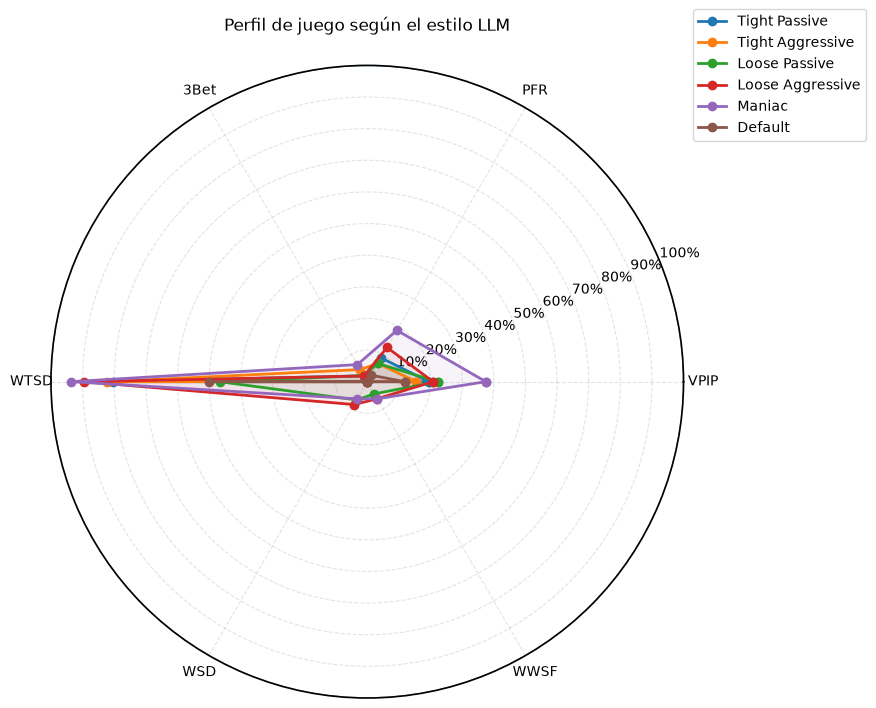

In [6]:
# ============================================================
# GRÁFICA 4 — RADAR: ESTILOS LLM
# ============================================================

datos_radar = resumen_estilos[
    METRICAS
].fillna(0)

angulos = np.linspace(
    0,
    2 * np.pi,
    len(METRICAS),
    endpoint=False
).tolist()

angulos += angulos[:1]

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={
        "polar": True
    }
)

for nombre in datos_radar.index:

    valores = datos_radar.loc[
        nombre,
        METRICAS
    ].tolist()

    valores += valores[:1]

    ax.plot(
        angulos,
        valores,
        marker="o",
        linewidth=2,
        label=nombre
    )

    ax.fill(
        angulos,
        valores,
        alpha=0.08
    )

ax.set_ylim(
    0,
    100
)

# Marcar claramente los extremos 0% y 100%.
ax.spines["polar"].set_linewidth(1.2)

# Mostrar claramente los extremos del eje.
ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    100,
    linewidth=1.2,
    alpha=0.65
)

ax.set_yticks(
    np.arange(0, 101, 10)
)

ax.set_yticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.set_xticks(
    angulos[:-1]
)

ax.set_xticklabels(
    METRICAS
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

ax.set_title(
    "Perfil de juego según el estilo LLM",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.30, 1.10)
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_0_estilos_radar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


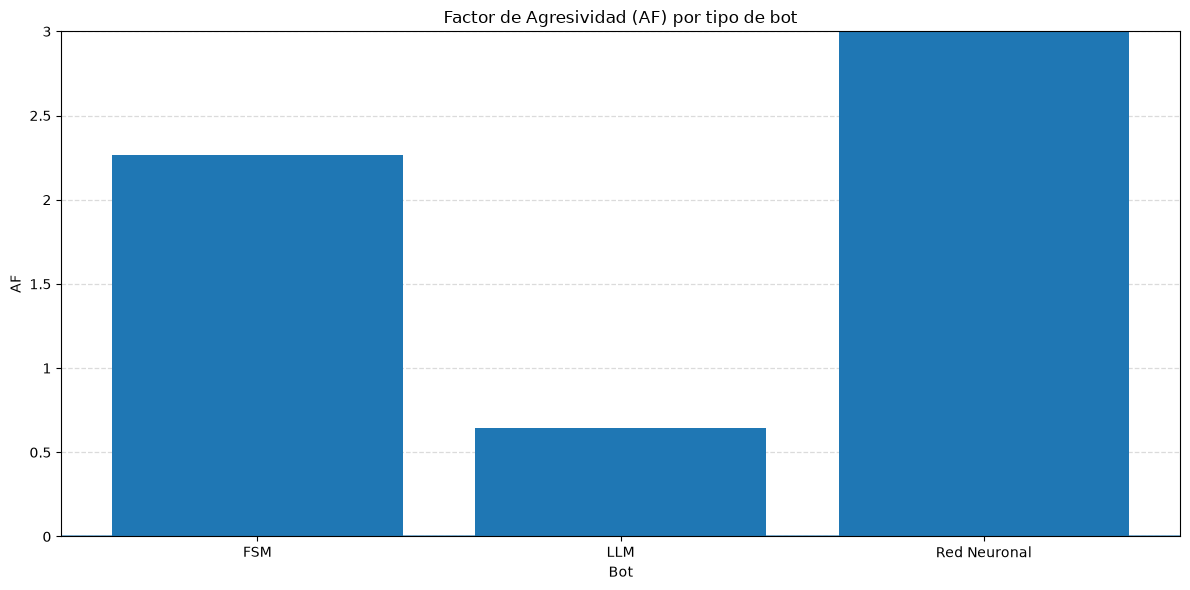

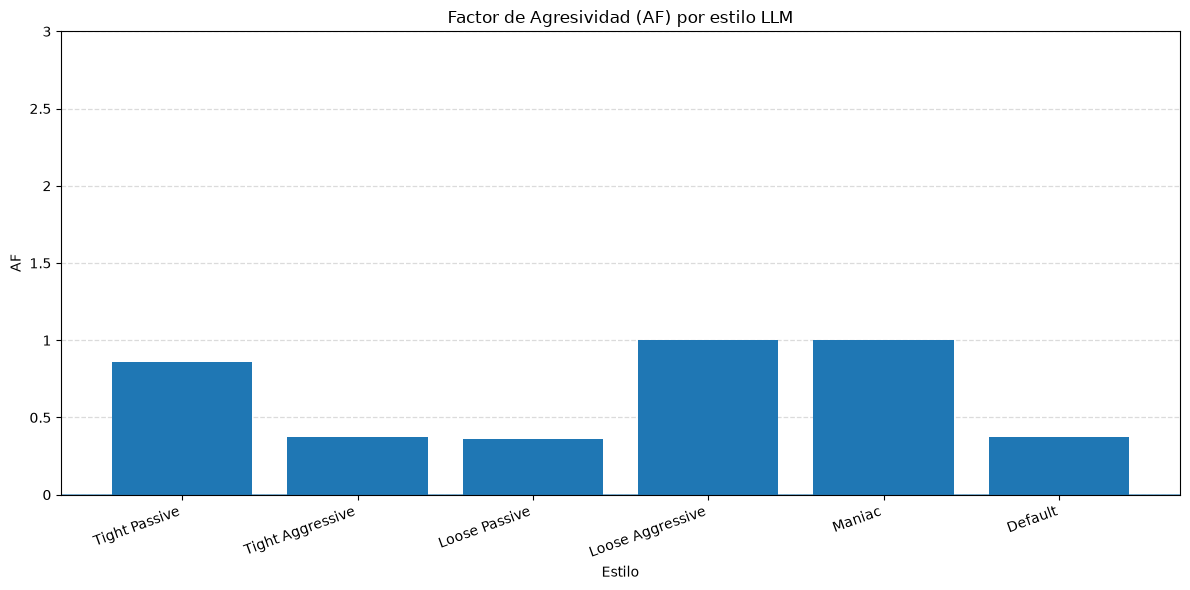

In [7]:
# ============================================================
# GRÁFICAS — FACTOR DE AGRESIVIDAD (AF)
# ============================================================

def calcular_af(datos, grupo):

    resumen = (
        datos
        .groupby(grupo, dropna=False)
        .agg(
            Calls=("Calls", "sum"),
            Bets=("Bets", "sum"),
            Raises=("Raises", "sum")
        )
    )

    resumen["AF"] = np.where(
        resumen["Calls"] > 0,
        (resumen["Bets"] + resumen["Raises"]) / resumen["Calls"],
        np.nan
    )

    return resumen


# ------------------------------------------------------------
# AF POR TIPO DE BOT
# ------------------------------------------------------------

af_bots = calcular_af(
    df_bots,
    "Type"
)

nombres_tipos = {
    "BOT_LLM": "LLM",
    "BOT_NN": "Red Neuronal",
    "BOT_FSM": "FSM"
}

af_bots.index = [
    nombres_tipos.get(x, x)
    for x in af_bots.index
]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

x = np.arange(
    len(af_bots)
)

ax.bar(
    x,
    af_bots["AF"]
)

ax.set_title(
    "Factor de Agresividad (AF) por tipo de bot"
)

ax.set_xlabel(
    "Bot"
)

ax.set_ylabel(
    "AF"
)

ax.set_xticks(x)
ax.set_xticklabels(af_bots.index)

# Límite fijo: 0 a 3.
ax.set_ylim(
    0,
    3
)

ax.set_yticks(
    np.arange(0, 3.1, 0.5)
)

ax.set_yticklabels(
    ["0", "0.5", "1", "1.5", "2", "2.5", "3"]
)

# Marcar claramente los extremos.
ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    3,
    linewidth=1.2,
    alpha=0.65
)

ax.grid(False)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.xaxis.grid(False)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_0_af_bots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# AF POR ESTILO LLM
# ------------------------------------------------------------

af_estilos = calcular_af(
    df_llm,
    "Style"
)

af_estilos = af_estilos.reindex(
    ESTILOS
)

af_estilos.index = [
    NOMBRES_ESTILOS.get(x, x)
    for x in af_estilos.index
]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

x = np.arange(
    len(af_estilos)
)

ax.bar(
    x,
    af_estilos["AF"]
)

ax.set_title(
    "Factor de Agresividad (AF) por estilo LLM"
)

ax.set_xlabel(
    "Estilo"
)

ax.set_ylabel(
    "AF"
)

ax.set_xticks(x)

ax.set_xticklabels(
    af_estilos.index,
    rotation=20,
    ha="right"
)

# Misma escala fija 0-3 para mantener uniformidad.
ax.set_ylim(
    0,
    3
)

ax.set_yticks(
    np.arange(0, 3.1, 0.5)
)

ax.set_yticklabels(
    ["0", "0.5", "1", "1.5", "2", "2.5", "3"]
)

ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    3,
    linewidth=1.2,
    alpha=0.65
)

ax.grid(False)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.xaxis.grid(False)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_0_af_estilos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [8]:
# ============================================================
# COMPROBACIÓN FINAL
# ============================================================

print("========== RESUMEN DEL PUNTO 0 ==========")

print()
print("Bots:")
display(resumen_bots.round(2))

print()
print("Estilos LLM:")
display(resumen_estilos.round(2))

print()
print("Acciones utilizadas para AF:")
display(
    df_bots[
        ["Type", "Style", "Calls", "Bets", "Raises"]
    ].head(10)
)

print()
print("Archivos generados:")
for archivo in sorted(OUTPUT_DIR.glob("punto_0_*")):
    print(" -", archivo.name)


========== RESUMEN DEL PUNTO 0 ==========

Bots:


,VPIP,PFR,3Bet,WTSD,WSD,WWSF
FSM,37.62,28.71,17.82,84.16,18.81,14.85
LLM,19.42,8.26,2.48,71.90,3.31,2.48
Red Neuronal,72.28,68.32,1.98,45.54,18.81,14.85



Estilos LLM:


,VPIP,PFR,3Bet,WTSD,WSD,WWSF
Tight Passive,19.57,8.70,2.17,80.43,0.00,0.00
Tight Aggressive,15.56,6.67,4.44,82.22,0.00,0.00
Loose Passive,22.22,6.67,2.22,46.67,6.67,4.44
Loose Aggressive,20.83,12.50,2.08,89.58,8.33,6.25
Maniac,37.50,18.75,6.25,93.75,6.25,6.25
Default,11.90,2.38,0.00,50.00,0.00,0.00



Acciones utilizadas para AF:


,Type,Style,Calls,Bets,Raises
1,BOT_LLM,DEFAULT,0,0,0
2,BOT_LLM,DEFAULT,3,1,0
3,BOT_NN,DEFAULT,0,0,1
4,BOT_FSM,DEFAULT,1,1,1
5,BOT_LLM,DEFAULT,2,0,1
6,BOT_LLM,DEFAULT,0,0,0
7,BOT_NN,DEFAULT,0,0,2
8,BOT_FSM,DEFAULT,0,0,0
10,BOT_NN,DEFAULT,1,0,1
11,BOT_FSM,DEFAULT,0,0,0



Archivos generados:
 - punto_0_af_bots.png
 - punto_0_af_estilos.png
 - punto_0_bots_barras.png
 - punto_0_bots_radar.png
 - punto_0_estilos_barras.png
 - punto_0_estilos_radar.png


# 1. ¿Qué bot obtiene mejores resultados?

Se compara el rendimiento de los bots mediante Win Rate, chips ganadas o perdidas, número medio de manos hasta ganar, supervivencia y consistencia entre partidas.


In [9]:
# ============================================================
# DATOS DEL PUNTO 1
# ============================================================

df_p1 = df[
    df["Type"].isin(TIPOS_BOT)
].copy()

# ------------------------------------------------------------
# Último registro de cada jugador en cada partida
# ------------------------------------------------------------

final_jugadores = (
    df_p1
    .sort_values(
        ["Match", "PlayerId", "Hand"]
    )
    .groupby(
        ["Match", "PlayerId"],
        as_index=False
    )
    .tail(1)
    .copy()
)

# Número de manos en las que participa cada jugador.
manos_supervivencia = (
    df_p1
    .groupby(
        ["Match", "PlayerId"]
    )["Hand"]
    .max()
    .rename("ManosSupervivencia")
    .reset_index()
)

final_jugadores = final_jugadores.merge(
    manos_supervivencia,
    on=["Match", "PlayerId"],
    how="left"
)

# ------------------------------------------------------------
# Ganador de cada partida
# ------------------------------------------------------------

ganadores = (
    final_jugadores
    .sort_values(
        ["Match", "Final stack"],
        ascending=[True, False]
    )
    .groupby("Match")
    .head(1)
    [["Match", "PlayerId"]]
    .rename(
        columns={
            "PlayerId": "WinnerId"
        }
    )
)

final_jugadores = final_jugadores.merge(
    ganadores,
    on="Match",
    how="left"
)

final_jugadores["Gano"] = (
    final_jugadores["PlayerId"] ==
    final_jugadores["WinnerId"]
)

# ------------------------------------------------------------
# Resultado económico de la partida
# ------------------------------------------------------------

final_jugadores["ChipsPartida"] = (
    final_jugadores["Final stack"] -
    final_jugadores["Initial stack"]
)

# ------------------------------------------------------------
# Manos hasta ganar
# ------------------------------------------------------------

final_jugadores["ManosHastaGanar"] = np.where(
    final_jugadores["Gano"],
    final_jugadores["Hand"] + 1,
    np.nan
)

# ------------------------------------------------------------
# Tipo de bot
# ------------------------------------------------------------

final_jugadores["Bot"] = (
    final_jugadores["Type"]
    .map({
        "BOT_LLM": "LLM",
        "BOT_NN": "Red Neuronal",
        "BOT_FSM": "FSM"
    })
    .fillna(final_jugadores["Type"])
)

# ------------------------------------------------------------
# Resumen por bot
# ------------------------------------------------------------

resumen_p1 = (
    final_jugadores
    .groupby("Bot")
    .agg(
        Win_Rate=("Gano", "mean"),
        Chips_Medias=("ChipsPartida", "mean"),
        Manos_Hasta_Ganar=("ManosHastaGanar", "mean"),
        Supervivencia=("ManosSupervivencia", "mean"),
        Partidas=("Match", "nunique")
    )
)

resumen_p1["Win_Rate"] *= 100

display(
    resumen_p1.round(2)
)


,Win_Rate,Chips_Medias,Manos_Hasta_Ganar,Supervivencia,Partidas
Bot,,,,,
FSM,10.00,-11.60,19.00,10.10,10
LLM,39.29,-0.11,9.45,8.64,12
Red Neuronal,0.00,-53.70,NaN,10.10,10


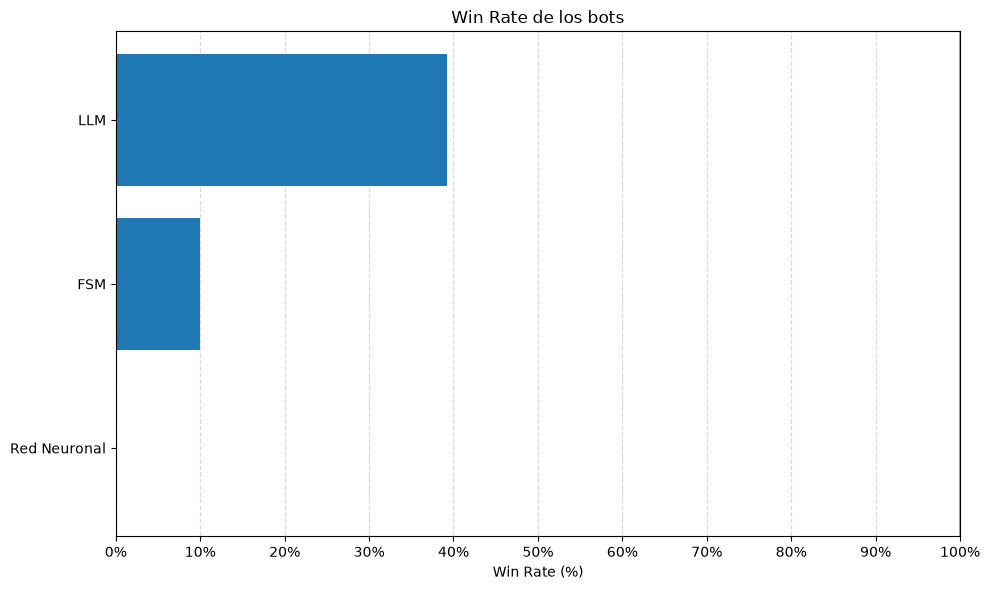

In [10]:
# ============================================================
# GRÁFICA — WIN RATE
# ============================================================

valores = resumen_p1["Win_Rate"].sort_values(
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.barh(
    valores.index,
    valores.values
)

ax.set_title(
    "Win Rate de los bots"
)

ax.set_xlabel(
    "Win Rate (%)"
)

ax.set_xlim(
    0,
    100
)

ax.set_xticks(
    np.arange(0, 101, 10)
)

ax.set_xticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.axvline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axvline(
    100,
    linewidth=1.2,
    alpha=0.65
)

ax.grid(False)

ax.xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.yaxis.grid(False)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_1_win_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


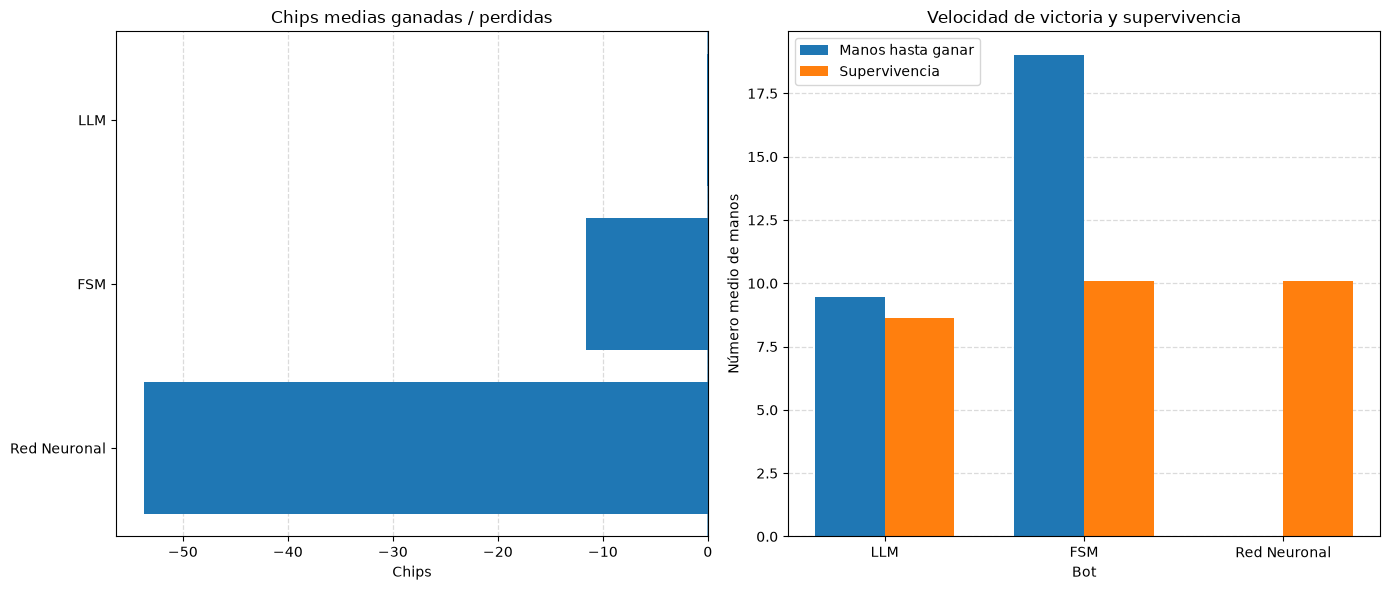

In [11]:
# ============================================================
# GRÁFICAS — CHIPS Y MANOS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)

# ------------------------------------------------------------
# Chips medias
# ------------------------------------------------------------

chips = resumen_p1["Chips_Medias"].sort_values()

axes[0].barh(
    chips.index,
    chips.values
)

axes[0].set_title(
    "Chips medias ganadas / perdidas"
)

axes[0].set_xlabel(
    "Chips"
)

axes[0].axvline(
    0,
    linewidth=1.2,
    alpha=0.65
)

axes[0].grid(False)

axes[0].xaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

axes[0].yaxis.grid(False)

axes[0].set_axisbelow(True)

# ------------------------------------------------------------
# Manos hasta ganar y supervivencia
# ------------------------------------------------------------

tabla_manos = resumen_p1[
    [
        "Manos_Hasta_Ganar",
        "Supervivencia"
    ]
].copy()

tabla_manos = tabla_manos.sort_values(
    "Manos_Hasta_Ganar",
    ascending=True
)

x = np.arange(
    len(tabla_manos)
)

width = 0.35

axes[1].bar(
    x - width / 2,
    tabla_manos["Manos_Hasta_Ganar"],
    width,
    label="Manos hasta ganar"
)

axes[1].bar(
    x + width / 2,
    tabla_manos["Supervivencia"],
    width,
    label="Supervivencia"
)

axes[1].set_title(
    "Velocidad de victoria y supervivencia"
)

axes[1].set_ylabel(
    "Número medio de manos"
)

axes[1].set_xlabel(
    "Bot"
)

axes[1].set_xticks(
    x
)

axes[1].set_xticklabels(
    tabla_manos.index
)

axes[1].grid(False)

axes[1].yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

axes[1].xaxis.grid(False)

axes[1].set_axisbelow(True)

axes[1].legend()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_1_chips_manos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


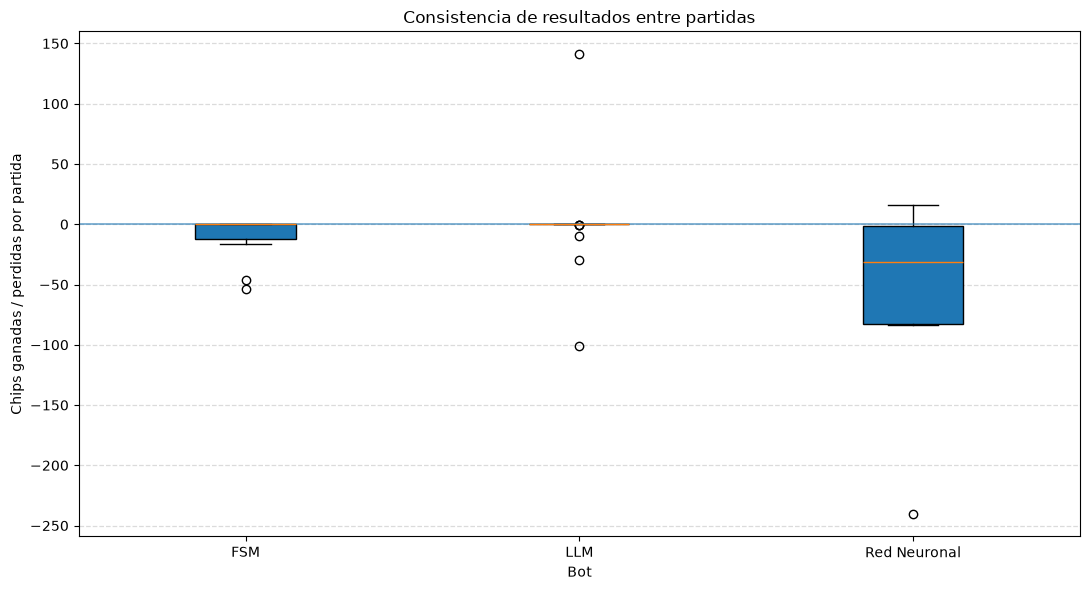

In [13]:
# ============================================================
# GRÁFICA — CONSISTENCIA ENTRE PARTIDAS
# ============================================================

datos_boxplot = []
etiquetas = []

for bot in resumen_p1.index:

    valores = (
        final_jugadores
        .loc[
            final_jugadores["Bot"] == bot,
            "ChipsPartida"
        ]
        .dropna()
    )

    datos_boxplot.append(
        valores.values
    )

    etiquetas.append(
        bot
    )

fig, ax = plt.subplots(
    figsize=(11, 6)
)

ax.boxplot(
    datos_boxplot,
    tick_labels=etiquetas,
    patch_artist=True
)

ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.set_title(
    "Consistencia de resultados entre partidas"
)

ax.set_xlabel(
    "Bot"
)

ax.set_ylabel(
    "Chips ganadas / perdidas por partida"
)

ax.grid(False)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.xaxis.grid(False)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_1_consistencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [14]:
# ============================================================
# COMPROBACIÓN DEL PUNTO 1
# ============================================================

print("========== RESUMEN DEL PUNTO 1 ==========")

display(
    resumen_p1.round(2)
)

print(
    "Partidas analizadas:",
    final_jugadores["Match"].nunique()
)

print(
    "Registros finales de bots:",
    len(final_jugadores)
)

print()
print("========== COMPROBACIÓN DE STACKS ==========")

display(
    final_jugadores[
        [
            "Match",
            "Player",
            "Type",
            "Initial stack",
            "Final stack",
            "ChipsPartida",
            "Gano"
        ]
    ].head(10)
)


========== RESUMEN DEL PUNTO 1 ==========


,Win_Rate,Chips_Medias,Manos_Hasta_Ganar,Supervivencia,Partidas
Bot,,,,,
FSM,10.00,-11.60,19.00,10.10,10
LLM,39.29,-0.11,9.45,8.64,12
Red Neuronal,0.00,-53.70,NaN,10.10,10


Partidas analizadas: 12
Registros finales de bots: 48

========== COMPROBACIÓN DE STACKS ==========


,Match,Player,Type,Initial stack,Final stack,ChipsPartida,Gano
0,match_20260814_211527_418_001,GeminiLLM#1-DEFAULT#1,BOT_LLM,50.0,49.0,-1.0,True
1,match_20260814_211527_418_001,LlamaPokerLLM#2-DEFAULT#2,BOT_LLM,0.0,0.0,0.0,False
2,match_20260814_211527_418_001,DeepCFR#3-DEFAULT#3,BOT_NN,0.0,0.0,0.0,False
3,match_20260814_211527_418_001,FSM#4-DEFAULT#4,BOT_FSM,0.0,0.0,0.0,False
4,match_20260814_230242_566_001,LlamaPokerLLM#1-TIGHT_PASSIVE#1,BOT_LLM,0.0,0.0,0.0,True
5,match_20260814_230242_566_001,LlamaPokerLLM#2-LOOSE_AGGRESSIVE#2,BOT_LLM,0.0,0.0,0.0,False
6,match_20260814_230242_566_001,DeepCFR#3-DEFAULT#3,BOT_NN,2.0,0.0,-2.0,False
7,match_20260814_230242_566_001,FSM#4-DEFAULT#4,BOT_FSM,0.0,0.0,0.0,False
8,match_20260814_230829_581_002,LlamaPokerLLM#1-TIGHT_PASSIVE#1,BOT_LLM,0.0,0.0,0.0,True
9,match_20260814_230829_581_002,LlamaPokerLLM#2-LOOSE_AGGRESSIVE#2,BOT_LLM,0.0,0.0,0.0,False


# 2. ¿Los estilos de juego realmente se comportan de forma diferente?

Se comparan los estilos Tight Passive, Tight Aggressive, Loose Passive, Loose Aggressive, Maniac y Default mediante VPIP, PFR, 3Bet, WTSD, WSD, WWSF y AF.


In [166]:
# ============================================================
# DATOS DEL PUNTO 2
# ============================================================

# IMPORTANTE:
# El estilo procede exclusivamente del campo Style del bloque
# *** EXPERIMENT *** de cada log.

df_p2 = df[
    (df["Type"] == "BOT_LLM") &
    (df["Style"].isin(ESTILOS))
].copy()

resumen_estilos_p2 = (
    df_p2
    .groupby(
        "Style",
        observed=True
    )[METRICAS]
    .mean()
    * 100
)

resumen_estilos_p2 = resumen_estilos_p2.reindex(
    ESTILOS
)

resumen_estilos_p2.index = [
    NOMBRES_ESTILOS.get(
        x,
        x
    )
    for x in resumen_estilos_p2.index
]

print("Registros LLM analizados:", len(df_p2))
print("Estilos encontrados:")
print(df_p2["Style"].value_counts(dropna=False))

display(
    resumen_estilos_p2.round(2)
)


Registros LLM analizados: 92
Estilos encontrados:
Style
TIGHT_PASSIVE       31
MANIAC              21
LOOSE_AGGRESSIVE    19
DEFAULT             17
TIGHT_AGGRESSIVE     4
Name: count, dtype: int64


,VPIP,PFR,3Bet,WTSD,WSD,WWSF
Tight Passive,22.58,3.23,3.23,61.29,32.26,6.45
Tight Aggressive,25.00,0.00,0.00,100.00,25.00,25.00
Loose Passive,NaN,NaN,NaN,NaN,NaN,NaN
Loose Aggressive,36.84,5.26,5.26,68.42,57.89,21.05
Maniac,14.29,0.00,0.00,42.86,38.10,4.76
Default,11.76,0.00,0.00,47.06,47.06,23.53


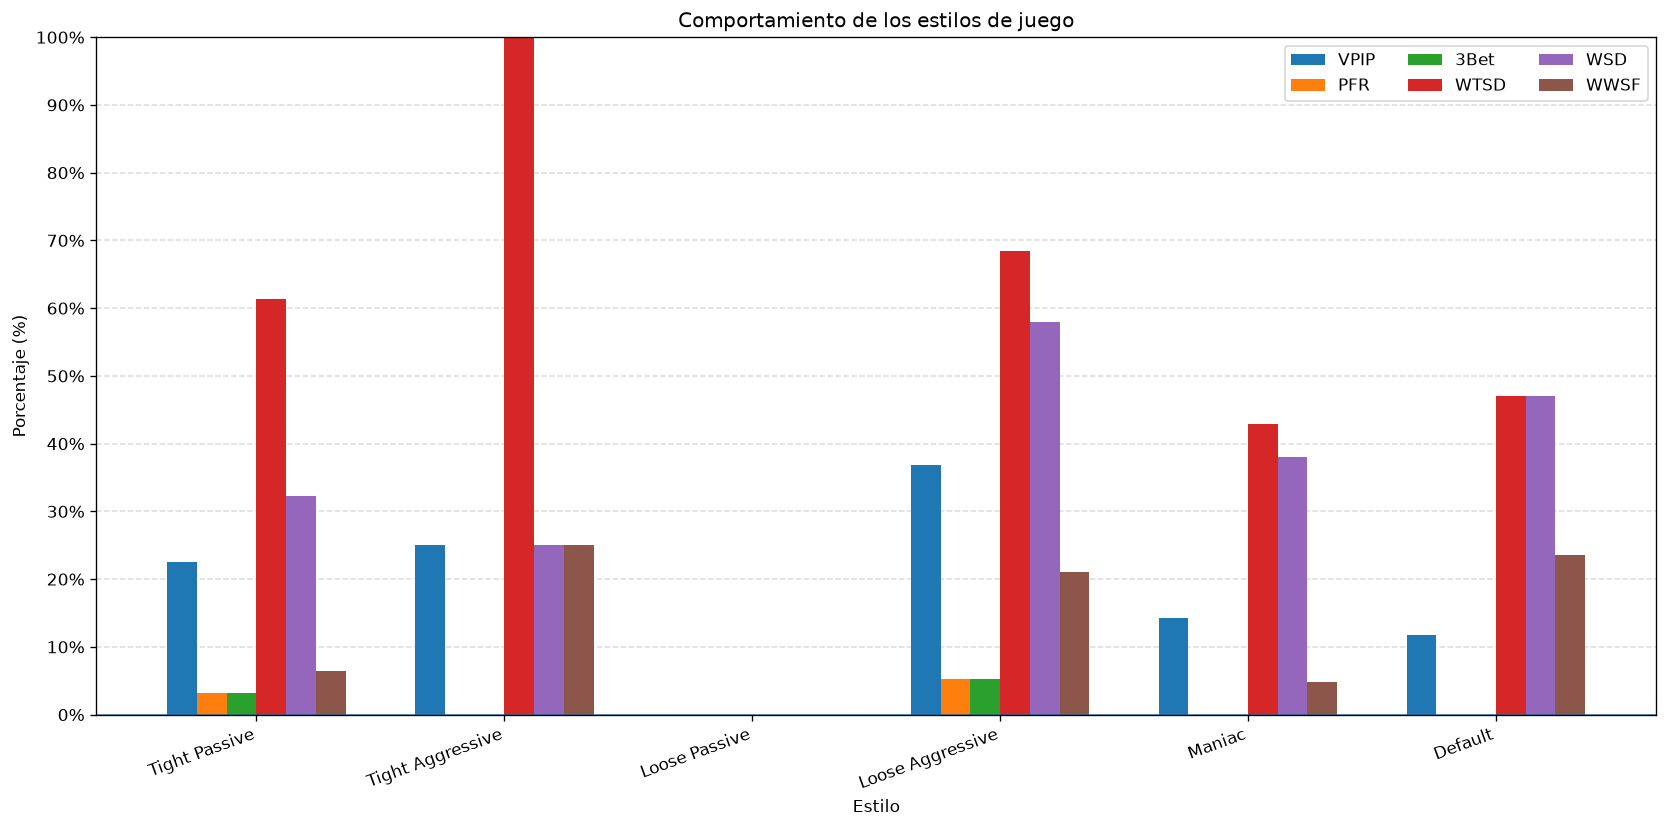

In [167]:
# ============================================================
# GRÁFICA — BARRAS: COMPARACIÓN DE ESTILOS
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)

x = np.arange(
    len(resumen_estilos_p2)
)

width = 0.12

offsets = np.linspace(
    -2.5 * width,
    2.5 * width,
    len(METRICAS)
)

for offset, metrica in zip(
    offsets,
    METRICAS
):

    ax.bar(
        x + offset,
        resumen_estilos_p2[metrica],
        width=width,
        label=metrica
    )

ax.set_title(
    "Comportamiento de los estilos de juego"
)

ax.set_xlabel(
    "Estilo"
)

ax.set_ylabel(
    "Porcentaje (%)"
)

ax.set_ylim(
    0,
    100
)

ax.set_yticks(
    np.arange(0, 101, 10)
)

ax.set_yticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    100,
    linewidth=1.2,
    alpha=0.65
)

ax.grid(False)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.xaxis.grid(False)

ax.set_axisbelow(True)

ax.set_xticks(x)

ax.set_xticklabels(
    resumen_estilos_p2.index,
    rotation=20,
    ha="right"
)

ax.legend(
    ncol=3
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_2_estilos_barras.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


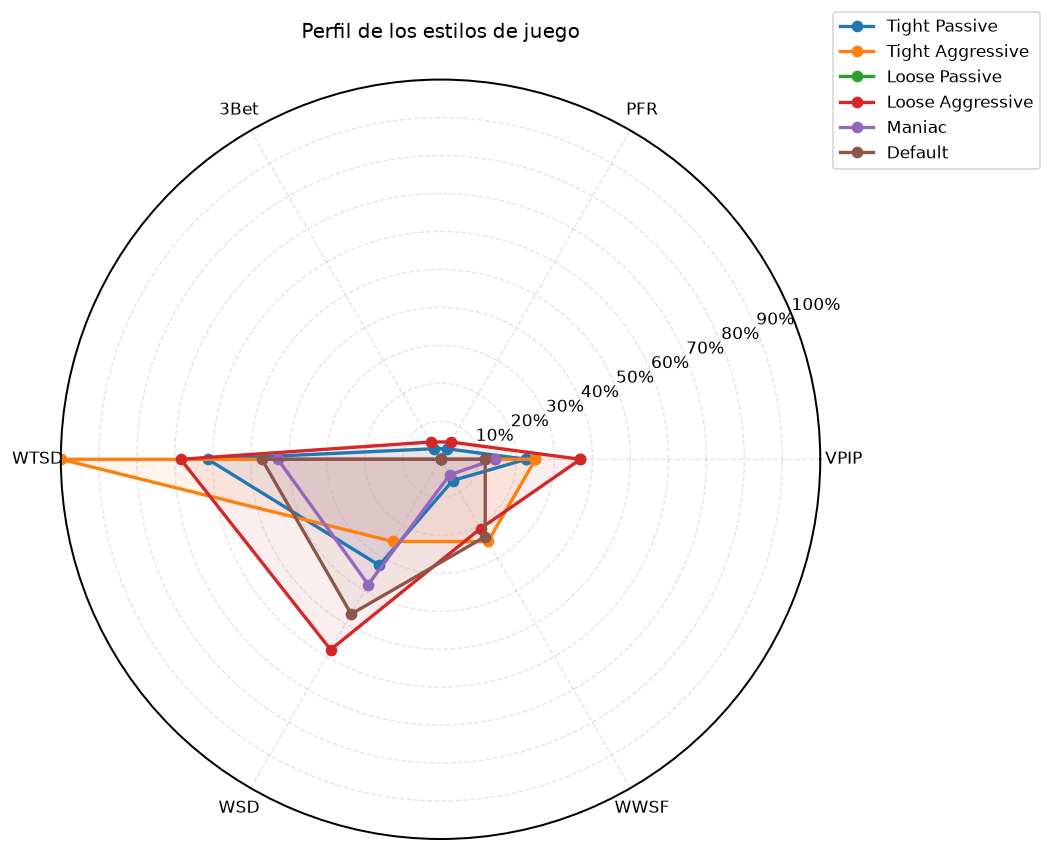

In [168]:
# ============================================================
# GRÁFICA — RADAR: PERFIL DE LOS ESTILOS
# ============================================================

datos_radar_p2 = resumen_estilos_p2[
    METRICAS
].fillna(0)

angulos = np.linspace(
    0,
    2 * np.pi,
    len(METRICAS),
    endpoint=False
).tolist()

angulos += angulos[:1]

fig, ax = plt.subplots(
    figsize=(9, 9),
    subplot_kw={
        "polar": True
    }
)

for nombre in datos_radar_p2.index:

    valores = datos_radar_p2.loc[
        nombre,
        METRICAS
    ].tolist()

    valores += valores[:1]

    ax.plot(
        angulos,
        valores,
        marker="o",
        linewidth=2,
        label=nombre
    )

    ax.fill(
        angulos,
        valores,
        alpha=0.08
    )

ax.set_ylim(
    0,
    100
)

ax.set_yticks(
    np.arange(0, 101, 10)
)

ax.set_yticklabels(
    [f"{i}%" for i in range(0, 101, 10)]
)

ax.set_xticks(
    angulos[:-1]
)

ax.set_xticklabels(
    METRICAS
)

ax.grid(
    True,
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

ax.spines["polar"].set_linewidth(
    1.2
)

ax.set_title(
    "Perfil de los estilos de juego",
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.30, 1.10)
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_2_estilos_radar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


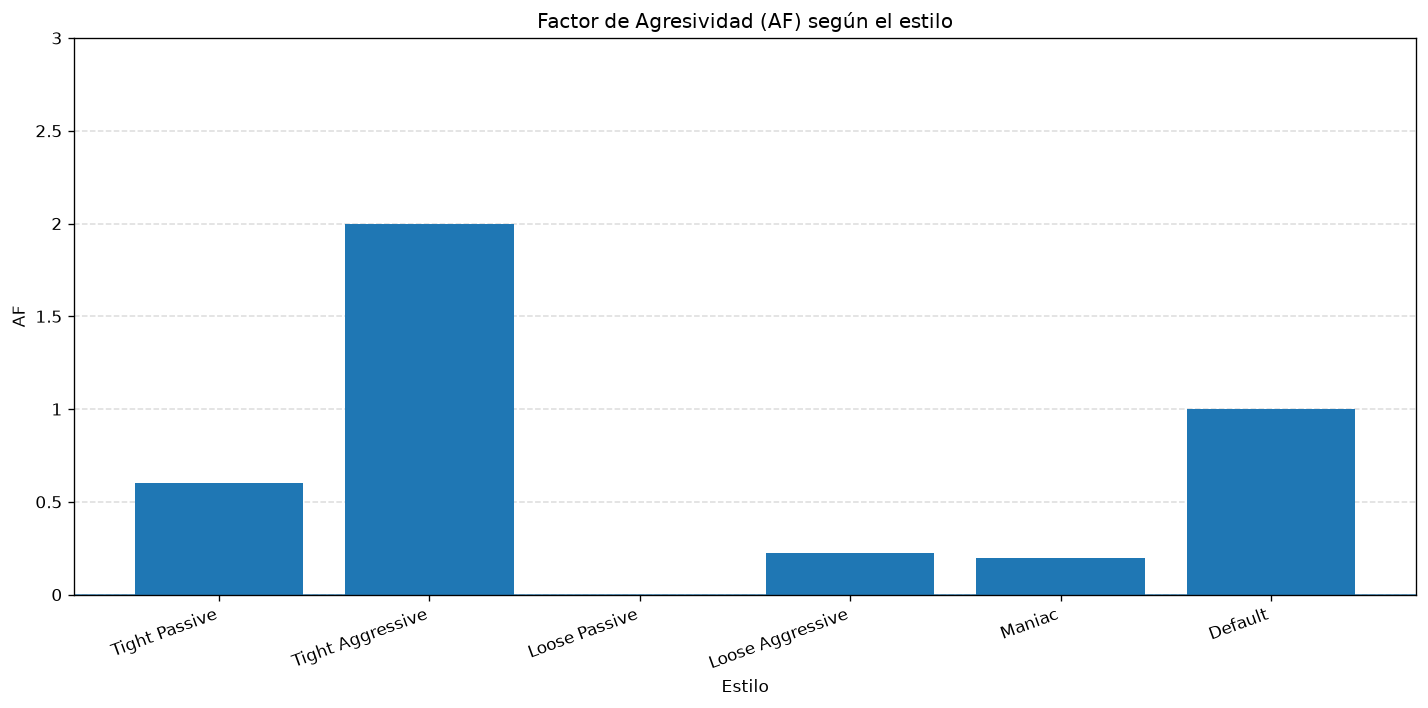

In [169]:
# ============================================================
# GRÁFICA — AF: AGRESIVIDAD SEGÚN EL ESTILO
# ============================================================

af_estilos_p2 = (
    df_p2
    .groupby(
        "Style",
        observed=True
    )
    .agg(
        Calls=("Calls", "sum"),
        Bets=("Bets", "sum"),
        Raises=("Raises", "sum")
    )
)

af_estilos_p2["AF"] = np.where(
    af_estilos_p2["Calls"] > 0,
    (
        af_estilos_p2["Bets"] +
        af_estilos_p2["Raises"]
    ) / af_estilos_p2["Calls"],
    np.nan
)

af_estilos_p2 = af_estilos_p2.reindex(
    ESTILOS
)

af_estilos_p2.index = [
    NOMBRES_ESTILOS.get(
        x,
        x
    )
    for x in af_estilos_p2.index
]

fig, ax = plt.subplots(
    figsize=(12, 6)
)

x = np.arange(
    len(af_estilos_p2)
)

ax.bar(
    x,
    af_estilos_p2["AF"]
)

ax.set_title(
    "Factor de Agresividad (AF) según el estilo"
)

ax.set_xlabel(
    "Estilo"
)

ax.set_ylabel(
    "AF"
)

ax.set_xticks(x)

ax.set_xticklabels(
    af_estilos_p2.index,
    rotation=20,
    ha="right"
)

# Escala fija para poder comparar entre gráficos.
ax.set_ylim(
    0,
    3
)

ax.set_yticks(
    np.arange(0, 3.1, 0.5)
)

ax.set_yticklabels(
    ["0", "0.5", "1", "1.5", "2", "2.5", "3"]
)

ax.axhline(
    0,
    linewidth=1.2,
    alpha=0.65
)

ax.axhline(
    3,
    linewidth=1.2,
    alpha=0.65
)

ax.grid(False)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.9,
    alpha=0.45
)

ax.xaxis.grid(False)

ax.set_axisbelow(True)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "punto_2_af_estilos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [170]:
# ============================================================
# COMPROBACIÓN DEL PUNTO 2
# ============================================================

print("========== PUNTO 2 ==========")
print("Estilos analizados:", len(resumen_estilos_p2))
print("Registros:", len(df_p2))

display(
    resumen_estilos_p2.round(2)
)

display(
    af_estilos_p2[
        ["Calls", "Bets", "Raises", "AF"]
    ].round(2)
)


========== PUNTO 2 ==========
Estilos analizados: 6
Registros: 92


,VPIP,PFR,3Bet,WTSD,WSD,WWSF
Tight Passive,22.58,3.23,3.23,61.29,32.26,6.45
Tight Aggressive,25.00,0.00,0.00,100.00,25.00,25.00
Loose Passive,NaN,NaN,NaN,NaN,NaN,NaN
Loose Aggressive,36.84,5.26,5.26,68.42,57.89,21.05
Maniac,14.29,0.00,0.00,42.86,38.10,4.76
Default,11.76,0.00,0.00,47.06,47.06,23.53


,Calls,Bets,Raises,AF
Tight Passive,10.0,4.0,2.0,0.60
Tight Aggressive,1.0,2.0,0.0,2.00
Loose Passive,NaN,NaN,NaN,NaN
Loose Aggressive,9.0,1.0,1.0,0.22
Maniac,5.0,1.0,0.0,0.20
Default,2.0,0.0,2.0,1.00
